# CS982 Big Data Technologies - Pettan Battle Card Analysis

This notebook analyses a structured dataset of Dragon Ball Z Pettan Battle cards. The project is framed as a compact big-data workflow case study: data cleaning, feature engineering, statistical testing, unsupervised segmentation and supervised prediction are kept in one reproducible pipeline.

The analysis is organised around three research questions:

1. Do Gold and Platinum cards have significantly higher HP and Attack than Silver and Bronze cards?
2. Can cards be grouped into interpretable archetypes using only HP and Attack?
3. How accurately can high-tier rarity be predicted from card statistics alone?

The dataset is small, so the emphasis is on sound methodology rather than distributed scale: transparent data preparation, leakage-aware modelling, validation, interpretability and limitations.


## 1. Setup and Dataset Loading

The notebook loads the cleaned card table from `data/processed/pettan_cards_clean.csv`. Column names are normalised, numerical fields are re-parsed where needed, and the binary target `is_high` is defined as Gold or Platinum versus Silver or Bronze.


In [1]:
from pathlib import Path
import os
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu
from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, silhouette_score
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
os.environ.setdefault("OMP_NUM_THREADS", "1")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 5)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "pettan_cards_clean.csv"

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Expected dataset at {DATA_PATH}. Run from the project root or notebooks folder.")

df = pd.read_csv(DATA_PATH)
df.columns = df.columns.str.strip().str.replace(r"\s+", " ", regex=True).str.lower()

print("Loaded shape:", df.shape)
display(df.head())
print("Columns:", list(df.columns))


Loaded shape: (295, 22)


,title,character,series,number,rarity,type,description,hp,attack,japan release date,...,attack_max,is_high_tier,main_type,alignment,release_gap_days,hp_max_raw,attack_max_raw,hp_for_model,attack_for_model,is_high
0,Pride Regained,Super Saiyan Vegeta,Series 2,44,gold,Extreme TEQ,Can be recruited from Summons.,8400,7000,2021-05-03,...,7000.0,1,TEQ,extreme,84.0,8400.0,7000.0,8400.0,7000.0,1
1,Time-traversing Evil,Cell (1st Form),Series 3,104,bronze,TEQ,Can be recruited from Summons.,3700,2450,2021-07-26,...,2450.0,0,TEQ,NaN,42.0,3700.0,2450.0,3700.0,2450.0,0
2,Red Ribbon Army's Grudge,Dr. Gero,Series 2,55,silver,Extreme INT,Can be recruited from Summons.,5700,3800,2021-05-03,...,3800.0,0,INT,extreme,84.0,5700.0,3800.0,5700.0,3800.0,0
3,Infinite Fighting Spirit,Android #17,Series 2,57,silver,Extreme TEQ,Can be recruited from Summons.,6100,4050,2021-05-03,...,4050.0,0,TEQ,extreme,84.0,6100.0,4050.0,6100.0,4050.0,0
4,Alluring Assassin,Android #18,Series 3,93,silver,Extreme STR,Can be recruited from Summons.,6100,4050,2021-07-26,...,4050.0,0,STR,extreme,42.0,6100.0,4050.0,6100.0,4050.0,0


Columns: ['title', 'character', 'series', 'number', 'rarity', 'type', 'description', 'hp', 'attack', 'japan release date', 'global release date', 'hp_max', 'attack_max', 'is_high_tier', 'main_type', 'alignment', 'release_gap_days', 'hp_max_raw', 'attack_max_raw', 'hp_for_model', 'attack_for_model', 'is_high']


## 2. Feature Engineering and Data Quality Audit

HP and Attack can appear as raw text or as pre-computed numeric columns. To keep the modelling pipeline robust, the final numeric token is parsed from each raw field and used as the fully upgraded value. If parsing fails, the existing numeric fallback columns are used.

The target variable is derived only from rarity labels. It is not used as an input feature in the supervised model, which keeps the prediction task leakage-aware.


In [2]:
def parse_last_number(value):
    if pd.isna(value):
        return np.nan
    if isinstance(value, (int, float, np.integer, np.floating)):
        return float(value)
    numbers = re.findall(r"[-+]?\d*\.?\d+", str(value))
    return float(numbers[-1]) if numbers else np.nan

if "hp" in df.columns:
    df["hp_max_raw"] = df["hp"].apply(parse_last_number)
if "attack" in df.columns:
    df["attack_max_raw"] = df["attack"].apply(parse_last_number)

hp_fallback = pd.to_numeric(df.get("hp_max"), errors="coerce") if "hp_max" in df.columns else np.nan
attack_fallback = pd.to_numeric(df.get("attack_max"), errors="coerce") if "attack_max" in df.columns else np.nan

df["hp_for_model"] = df["hp_max_raw"].where(df["hp_max_raw"].notna(), hp_fallback)
df["attack_for_model"] = df["attack_max_raw"].where(df["attack_max_raw"].notna(), attack_fallback)
df["rarity"] = df["rarity"].astype(str).str.strip().str.lower()
df["is_high"] = df["rarity"].isin(["gold", "platinum"]).astype(int)

quality = pd.DataFrame({
    "missing_values": df[["hp_for_model", "attack_for_model", "rarity", "is_high"]].isna().sum(),
    "unique_values": df[["hp_for_model", "attack_for_model", "rarity", "is_high"]].nunique(),
})

print("Nulls after building modelling features -> hp_for_model:", int(df["hp_for_model"].isna().sum()), "attack_for_model:", int(df["attack_for_model"].isna().sum()))
display(df[["hp_for_model", "attack_for_model", "rarity", "is_high"]].head())
display(quality)


Nulls after building modelling features -> hp_for_model: 0 attack_for_model: 0


,hp_for_model,attack_for_model,rarity,is_high
0,8400.0,7000.0,gold,1
1,3700.0,2450.0,bronze,0
2,5700.0,3800.0,silver,0
3,6100.0,4050.0,silver,0
4,6100.0,4050.0,silver,0


,missing_values,unique_values
hp_for_model,0,87
attack_for_model,0,84
rarity,0,4
is_high,0,2


## 3. Descriptive Analysis

Before modelling, the notebook checks rarity balance and summarises the two main numerical variables. This establishes the class imbalance and the rough scale of the features used in later statistical tests, clustering and classification.


Rarity counts:


,rarity,count
0,bronze,119
1,silver,97
2,gold,63
3,platinum,16


Feature summary:


,count,mean,median,std,min,max
hp_for_model,295.0,5712.20,5700.0,2352.41,2000.0,11400.0
attack_for_model,295.0,4640.17,3900.0,2444.48,2000.0,11400.0


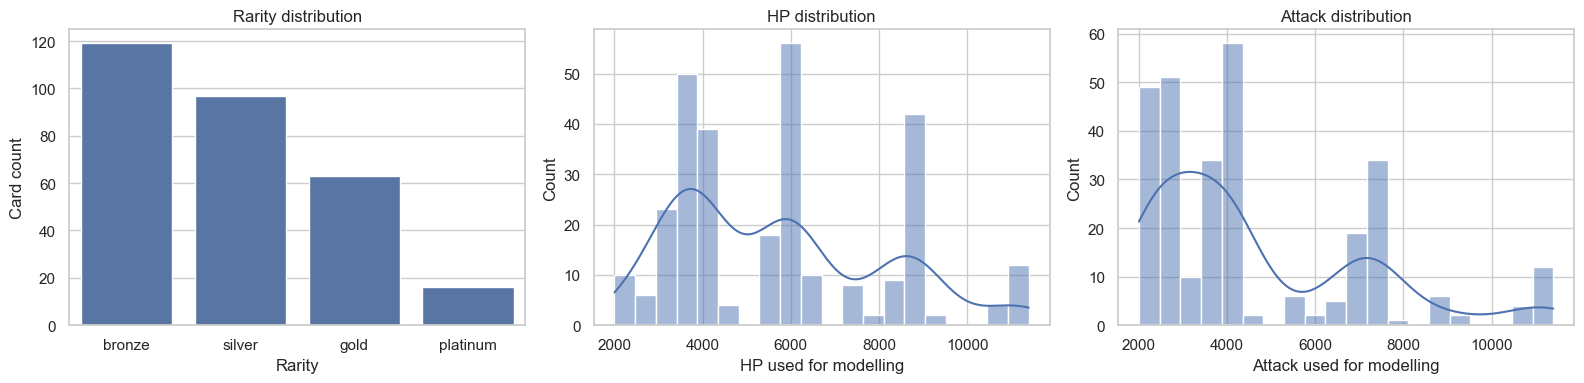

In [3]:
summary = df[["hp_for_model", "attack_for_model"]].describe().T[["count", "mean", "50%", "std", "min", "max"]]
summary = summary.rename(columns={"50%": "median"}).round(2)
rarity_counts = df["rarity"].value_counts().rename_axis("rarity").reset_index(name="count")

print("Rarity counts:")
display(rarity_counts)
print("Feature summary:")
display(summary)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.countplot(data=df, x="rarity", order=["bronze", "silver", "gold", "platinum"], ax=axes[0])
axes[0].set_title("Rarity distribution")
axes[0].set_xlabel("Rarity")
axes[0].set_ylabel("Card count")
sns.histplot(df["hp_for_model"], bins=20, kde=True, ax=axes[1])
axes[1].set_title("HP distribution")
axes[1].set_xlabel("HP used for modelling")
sns.histplot(df["attack_for_model"], bins=20, kde=True, ax=axes[2])
axes[2].set_title("Attack distribution")
axes[2].set_xlabel("Attack used for modelling")
plt.tight_layout()
plt.show()


## 4. Q1 - Statistical Comparison of High-tier and Low-tier Cards

Because the numerical distributions are skewed and class sizes differ, the comparison uses Mann-Whitney U tests rather than relying only on mean differences. Median differences are reported so the effect has a practical interpretation.


,feature,strategy,n_high,n_low,median_high,median_low,median_difference,mann_whitney_p
0,hp_for_model,complete-case,79,216,8700.0,4100.0,4600.0,1.559699e-39
1,hp_for_model,global-median,79,216,8700.0,4100.0,4600.0,1.559699e-39
2,hp_for_model,group-median,79,216,8700.0,4100.0,4600.0,1.559699e-39
3,attack_for_model,complete-case,79,216,7350.0,3200.0,4150.0,1.627610e-39
4,attack_for_model,global-median,79,216,7350.0,3200.0,4150.0,1.627610e-39
5,attack_for_model,group-median,79,216,7350.0,3200.0,4150.0,1.627610e-39


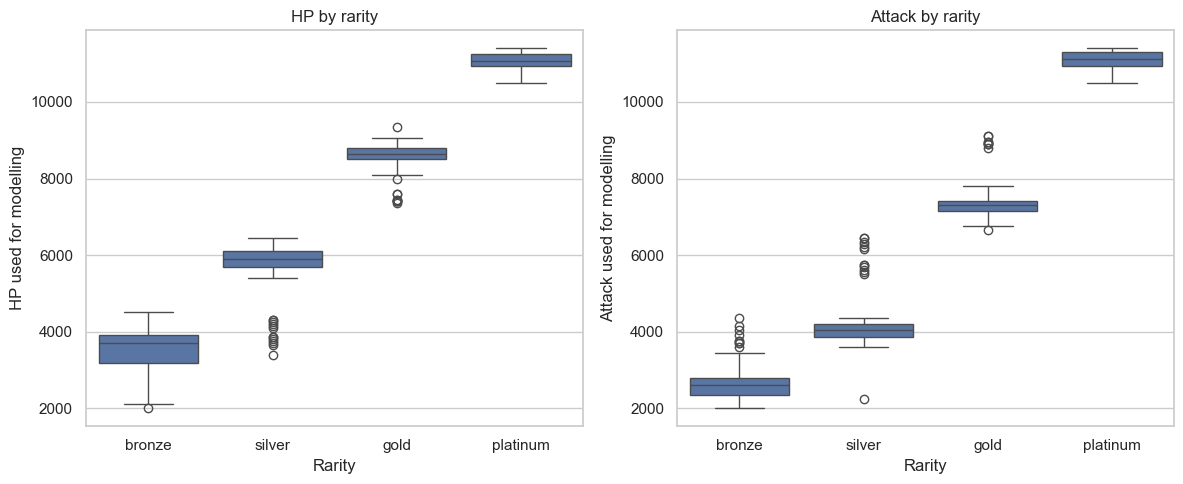

In [4]:
def q1_test(column):
    analysis = df[[column, "rarity", "is_high"]].copy()
    complete_case = analysis.dropna(subset=[column])
    global_median = analysis.copy()
    global_median[column] = global_median[column].fillna(global_median[column].median())
    group_median = analysis.copy()
    group_median[column] = group_median.groupby("rarity")[column].transform(lambda values: values.fillna(values.median()))

    rows = []
    for name, dataset in [("complete-case", complete_case), ("global-median", global_median), ("group-median", group_median)]:
        high = dataset.loc[dataset["is_high"] == 1, column].dropna().values
        low = dataset.loc[dataset["is_high"] == 0, column].dropna().values
        stat, p_value = mannwhitneyu(high, low, alternative="two-sided")
        rows.append({
            "feature": column,
            "strategy": name,
            "n_high": len(high),
            "n_low": len(low),
            "median_high": np.median(high),
            "median_low": np.median(low),
            "median_difference": np.median(high) - np.median(low),
            "mann_whitney_p": p_value,
        })
    return pd.DataFrame(rows)

q1_results = pd.concat([q1_test("hp_for_model"), q1_test("attack_for_model")], ignore_index=True)
display(q1_results)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=df, x="rarity", y="hp_for_model", order=["bronze", "silver", "gold", "platinum"], ax=axes[0])
axes[0].set_title("HP by rarity")
axes[0].set_xlabel("Rarity")
axes[0].set_ylabel("HP used for modelling")
sns.boxplot(data=df, x="rarity", y="attack_for_model", order=["bronze", "silver", "gold", "platinum"], ax=axes[1])
axes[1].set_title("Attack by rarity")
axes[1].set_xlabel("Rarity")
axes[1].set_ylabel("Attack used for modelling")
plt.tight_layout()
plt.show()


### Q1 Interpretation

Across complete-case, global-median and group-median variants, Gold/Platinum cards have much higher median HP and Attack than Silver/Bronze cards. The median HP gap is about 4,600 points and the median Attack gap is about 4,150 points, with extremely small Mann-Whitney p-values. The conclusion is therefore stable to the imputation strategy.


## 5. Q2 - Unsupervised Segmentation with K-Means

The clustering task uses only HP and Attack. Features are standardised before K-Means because the method is distance-based. The number of clusters is selected using silhouette score, with inertia shown as a secondary elbow diagnostic.


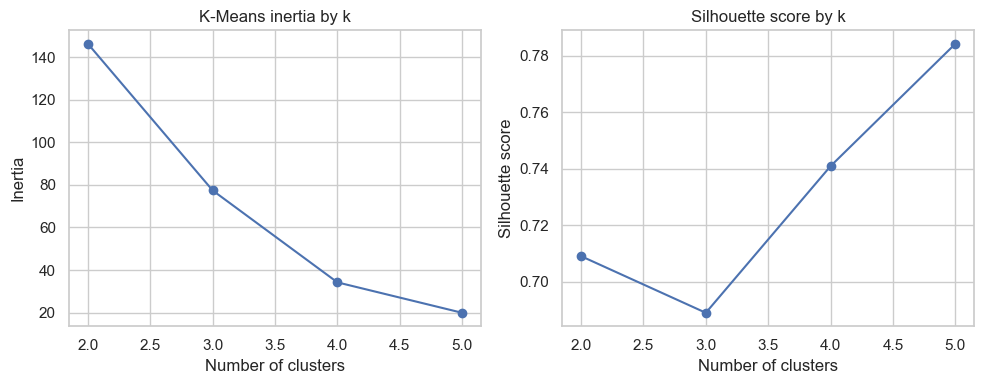

Chosen k (silhouette): 5


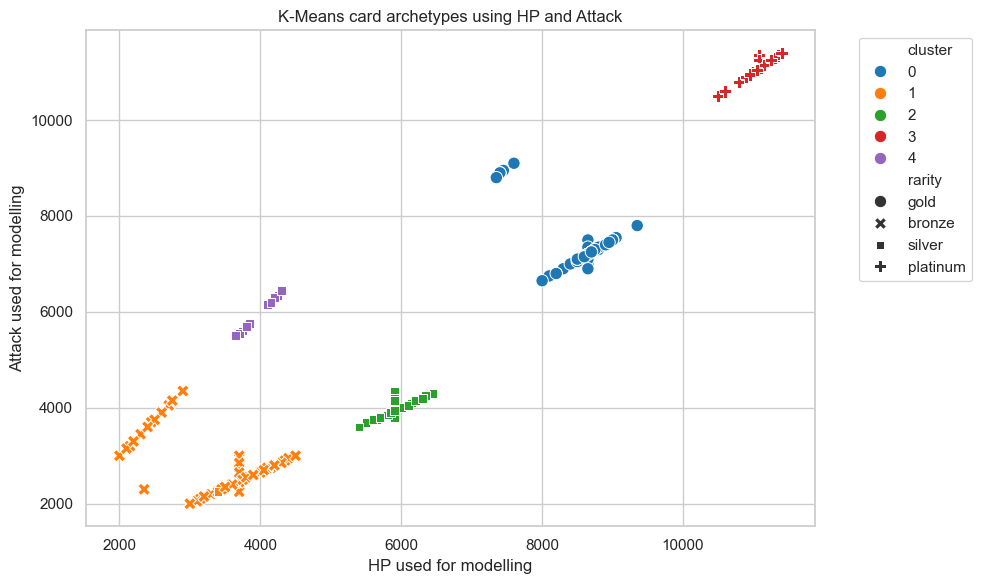

,hp_for_model,attack_for_model
cluster,,
0,8525.40,7445.24
1,3527.92,2631.67
2,5950.60,3986.90
3,11056.25,11084.38
4,3991.67,5979.17


In [5]:
cluster_df = df.dropna(subset=["hp_for_model", "attack_for_model"]).copy()
X_cluster = cluster_df[["hp_for_model", "attack_for_model"]].values
X_scaled = StandardScaler().fit_transform(X_cluster)

k_values = [2, 3, 4, 5]
inertias = []
silhouettes = []
for k in k_values:
    model = KMeans(n_clusters=k, n_init=20, random_state=42).fit(X_scaled)
    inertias.append(model.inertia_)
    silhouettes.append(silhouette_score(X_scaled, model.labels_))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(k_values, inertias, marker="o")
axes[0].set_title("K-Means inertia by k")
axes[0].set_xlabel("Number of clusters")
axes[0].set_ylabel("Inertia")
axes[1].plot(k_values, silhouettes, marker="o")
axes[1].set_title("Silhouette score by k")
axes[1].set_xlabel("Number of clusters")
axes[1].set_ylabel("Silhouette score")
plt.tight_layout()
plt.show()

best_k = k_values[int(np.nanargmax(silhouettes))]
final_kmeans = KMeans(n_clusters=best_k, n_init=30, random_state=42).fit(X_scaled)
cluster_df["cluster"] = final_kmeans.labels_
print("Chosen k (silhouette):", best_k)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=cluster_df,
    x="hp_for_model",
    y="attack_for_model",
    hue="cluster",
    style="rarity",
    palette="tab10",
    s=80,
)
plt.title("K-Means card archetypes using HP and Attack")
plt.xlabel("HP used for modelling")
plt.ylabel("Attack used for modelling")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

cluster_profile = cluster_df.groupby("cluster")[["hp_for_model", "attack_for_model"]].mean().round(2)
display(cluster_profile)


### Q2 Interpretation

The selected five-cluster solution separates low-stat cards, mid-stat cards, high-stat balanced cards, high-attack specialists and very high-stat cards. This is useful as an exploratory segmentation, but it should not be treated as a natural taxonomy without additional domain validation because the clustering is based on only two numeric features.


## 6. Q3 - Supervised Prediction of High-tier Cards

The supervised task predicts whether a card is Gold/Platinum using only HP and Attack. A pipeline is used so imputation and scaling are fitted inside each training fold, preventing leakage from validation data. The dataset is imbalanced, so precision, recall, F1 and ROC-AUC are reported alongside accuracy.


In [6]:
X = df[["hp_for_model", "attack_for_model"]].values
y = df["is_high"].values

pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(class_weight="balanced", max_iter=2000, random_state=42)),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_validate(pipe, X, y, cv=cv, scoring=["accuracy", "precision", "recall", "f1", "roc_auc"])
cv_summary = pd.DataFrame({
    metric: [scores[f"test_{metric}"].mean(), scores[f"test_{metric}"].std()]
    for metric in ["accuracy", "precision", "recall", "f1", "roc_auc"]
}, index=["mean", "std"]).round(4)

print("Cross-validation summary:")
display(cv_summary)

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.30, random_state=42)
pipe.fit(X_train, y_train)
pred = pipe.predict(X_test)
proba = pipe.predict_proba(X_test)[:, 1]

print("Holdout classification report:")
print(classification_report(y_test, pred))
print("Holdout ROC AUC:", roc_auc_score(y_test, proba))
print("Confusion matrix:")
print(confusion_matrix(y_test, pred))


Cross-validation summary:


,accuracy,precision,recall,f1,roc_auc
mean,1.0,1.0,1.0,1.0,1.0
std,0.0,0.0,0.0,0.0,0.0


Holdout classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        65
           1       1.00      1.00      1.00        24

    accuracy                           1.00        89
   macro avg       1.00      1.00      1.00        89
weighted avg       1.00      1.00      1.00        89

Holdout ROC AUC: 1.0
Confusion matrix:
[[65  0]
 [ 0 24]]


### Q3 Interpretation

The model achieves perfect cross-validation and holdout scores using only HP and Attack. This should be interpreted carefully. It does not mean the model has discovered a complex hidden rule; rather, the target rarity tier is strongly encoded by the stat ranges in this dataset. The strong result is useful, but it also highlights the need to check whether future datasets follow the same design pattern.


## 7. Limitations and Future Work

Key limitations:

- The dataset is small, so results should be treated as a structured-data case study rather than a volume-scale big-data benchmark.
- Only two numerical modelling features are used, which makes the workflow interpretable but limits behavioural complexity.
- Rarity appears almost separable from HP and Attack, so the supervised problem is easier than many real-world classification tasks.
- Release-date information contains missingness and should be validated against primary sources before being used for temporal claims.

Useful extensions would include modelling multiple rarity classes directly, adding release-series effects, comparing K-Means with density-based clustering, and testing whether the same decision boundary generalises to later card releases.


## Reproducibility Note

The project keeps private files, screenshots, spreadsheets and PDFs out of version control. The public repository contains only the cleaned dataset, analysis notebook, utility code and summary reports needed to reproduce the technical workflow.
